In [1]:
import os
import chardet
import pandas as pd
from sklearn.model_selection import train_test_split

random_state = 7
no_of_active_features = 15

def get_encoding(file_path):
    with open(file_path, "rb") as f:
        data = f.read(10000)
    return chardet.detect(data).get("encoding")


def read_files(file_path: str):
    if file_path == None:
        print("Enter filepath")
        return

    false_feature_file = "rq2_vosoughi_False_features.csv"
    true_feature_file = "rq2_vosoughi_True_features.csv"
    true_file = os.path.join(file_path + os.path.sep + true_feature_file)
    false_file = os.path.join(file_path + os.path.sep + false_feature_file)

    vosoughi_false_df = pd.read_csv(
        false_file, index_col=0, sep=",", encoding=get_encoding(false_file)
    )
    vosoughi_true_df = pd.read_csv(
        true_file, index_col=0, sep=",", encoding=get_encoding(true_file)
    )
    vosoughi_df = pd.concat([vosoughi_false_df, vosoughi_true_df])
    return vosoughi_df


def filter_and_split_df(df: pd.DataFrame):

    test_size = 0.15

    filtered_df = df[(df.characteristic_distance != -99999) & (df.depth != 0)]
    filtered_df = filtered_df.drop(columns=["avg_cluster_coef"], axis=1)
    filtered_df = filtered_df.drop(["weakly_cc"], axis=1)
    total_features = no_of_active_features - 2

    X = filtered_df.iloc[:, 3:total_features]
    Y = filtered_df.iloc[:, total_features]
    X_train_val_full, X_test_full, y_train_val_full, y_test_full = train_test_split(
        X, Y, test_size=test_size, random_state=random_state
    )

    print(X_train_val_full.shape, X_test_full.shape, y_train_val_full.shape, y_test_full.shape)
    
    return X_train_val_full, X_test_full, y_train_val_full, y_test_full

x_train_val_full, x_test_full, y_train_val_full, y_test_full = filter_and_split_df(read_files('../'))

(32305, 10) (5702, 10) (32305,) (5702,)


In [20]:
# import pickle 

# with open("./x_train_val_full.pickle", "wb") as file:
#     pickle.dump(x_train_val_full, file)

# with open("./y_train_val_full.pickle", "wb") as file:
#     pickle.dump(y_train_val_full, file)

# with open("./x_test_full.pickle", "wb") as file:
#     pickle.dump(x_test_full, file)

# with open("./y_test_full.pickle", "wb") as file:
#     pickle.dump(y_test_full, file)

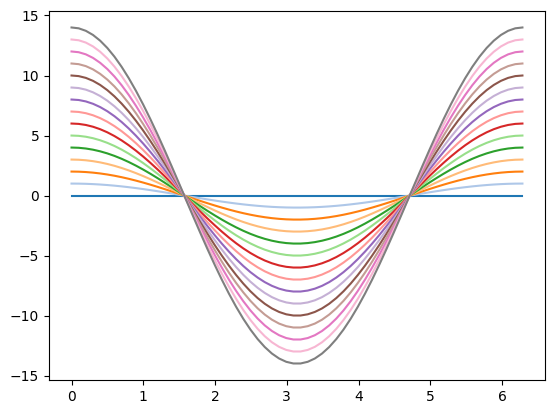

In [24]:
import numpy as np
import matplotlib.pylab as plt
import matplotlib.colors as cm

x = np.linspace(0, 2*np.pi, 64)
y = np.cos(x) 

plt.figure()

n = 15
color = iter([cm.to_hex(plt.cm.tab20(i)) for i in range(n)])

for i in range(n):
    plt.plot(x, i*y, color=next(color))

In [37]:
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE
from copy import copy
from sklearn.preprocessing import StandardScaler

total_features = 13

x_train_file = "./rq2_x_train_df.csv"

train_file = os.path.join(x_train_file)

train_df = pd.read_csv(
    train_file, index_col=0, sep=","
)

X_train_val = train_df.iloc[:, 3:total_features]
y_train_val = train_df.iloc[:, total_features]

normalized_df = copy(X_train_val)
cd_first_quantile = np.quantile(normalized_df["size"], 0.25)
cd_third_quantile = np.quantile(normalized_df["size"], 0.75)
normalized_df["depth"] = np.log(normalized_df["depth"])
normalized_df["size"] = np.log(normalized_df["size"])
normalized_df["max_breadth"] = np.log(normalized_df["max_breadth"])
normalized_df["strongly_cc"] = np.log(normalized_df["strongly_cc"])
normalized_df["characteristic_distance"] = np.log(
    normalized_df["characteristic_distance"]
    + cd_first_quantile**2 / cd_third_quantile
)

In [1]:
import pickle
import pandas as pd

def read_pickled_input_files(file_path: str):
    
    X_train_val = None
    y_train_val = None
    X_test = None
    y_test = None

    # wandb.init(project=wandb_project)

    with open(file_path + "/x_train_val_full.pickle", "rb") as file:
        X_train_val = pickle.load(file)
        # joblib.dump(X_train_val, "x_train_val.joblib")
        # x_train_val_artifact = wandb.Artifact("x_train_val.joblib", type="dataset")
        # x_train_val_artifact.add_file("x_train_val.joblib")
        # wandb.log_artifact(x_train_val_artifact)

    with open(file_path + "/y_train_val_full.pickle", "rb") as file:
        y_train_val = pickle.load(file)
        # joblib.dump(y_train_val, "y_train_val.joblib")
        # y_train_val_artifact = wandb.Artifact("y_train_val.joblib", type="dataset")
        # y_train_val_artifact.add_file("y_train_val.joblib")
        # wandb.log_artifact(y_train_val_artifact)

    with open(file_path + "/x_test_full.pickle", "rb") as file:
        X_test = pickle.load(file)
        # joblib.dump(X_test, "x_test.joblib")
        # x_test_artifact = wandb.Artifact("x_test.joblib", type="dataset")
        # x_test_artifact.add_file("x_test.joblib")
        # wandb.log_artifact(x_test_artifact)

    with open(file_path + "/y_test_full.pickle", "rb") as file:
        y_test = pickle.load(file)
        # joblib.dump(y_test, "y_test.joblib")
        # y_test_artifact = wandb.Artifact("y_test.joblib", type="dataset")
        # y_test_artifact.add_file("y_test.joblib")
        # wandb.log_artifact(y_test_artifact)

    # wandb.finish()
    
    return X_train_val, X_test, y_train_val, y_test

X_train_val, X_test, y_train_val, y_test = read_pickled_input_files("../image")

print(f"shapes of input: {X_train_val.shape}, {X_test.shape}, {y_train_val.shape}, {y_test.shape}")

shapes of input: (32305, 10), (5702, 10), (32305,), (5702,)


In [2]:
from copy import copy 
import numpy as np
from sklearn.preprocessing import StandardScaler

normalized_df = copy(X_train_val)
cd_first_quantile = np.quantile(normalized_df["characteristic_distance"], 0.25)
cd_third_quantile = np.quantile(normalized_df["characteristic_distance"], 0.75)
normalized_df["depth"] = np.log(normalized_df["depth"])
normalized_df["max_breadth"] = np.log(normalized_df["max_breadth"])
normalized_df["characteristic_distance"] = np.log(normalized_df["characteristic_distance"] + cd_first_quantile**2 / cd_third_quantile)
normalized_df["size"] = np.log(normalized_df["size"])
normalized_df["strongly_cc"] = np.log(normalized_df["strongly_cc"])

scaler = StandardScaler().set_output(transform="pandas")
scaled_X_train = scaler.fit_transform(normalized_df)


normalized_x_test = copy(X_test)
cd_first_quantile = np.quantile(normalized_x_test["characteristic_distance"], 0.25)
cd_third_quantile = np.quantile(normalized_x_test["characteristic_distance"], 0.75)
normalized_x_test["depth"] = np.log(normalized_x_test["depth"])
normalized_x_test["max_breadth"] = np.log(normalized_x_test["max_breadth"])
normalized_x_test["characteristic_distance"] = np.log(normalized_x_test["characteristic_distance"] + cd_first_quantile**2 / cd_third_quantile)
normalized_x_test["size"] = np.log(normalized_x_test["size"])
normalized_x_test["strongly_cc"] = np.log(normalized_x_test["strongly_cc"])

scaled_X_test = scaler.transform(normalized_x_test)

In [3]:
from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score,
    average_precision_score,
    fbeta_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix
)

def precision_0(y, y_pred):
    returned_arr = precision_score(y_true=y, y_pred=y_pred, average=None)
    return returned_arr[0]

def precision_1(y, y_pred):
    returned_arr = precision_score(y_true=y, y_pred=y_pred, average=None)
    return returned_arr[1]

def recall_0(y, y_pred):
    returned_arr = recall_score(y_true=y, y_pred=y_pred, average=None)
    return returned_arr[0]

def recall_1(y, y_pred):
    returned_arr = recall_score(y_true=y, y_pred=y_pred, average=None)
    return returned_arr[1]

scorers_for_gridcv = {
    "accuracy_score": make_scorer(accuracy_score),
    "precision_0": make_scorer(precision_0, greater_is_better=True),
    "precision_1": make_scorer(precision_1, greater_is_better=True),
    "recall_0": make_scorer(recall_0, greater_is_better=True),
    "recall_1": make_scorer(recall_1, greater_is_better=True),
    "fbeta_score": make_scorer(fbeta_score, beta=0.5),
    "balanced_accuracy_score": make_scorer(balanced_accuracy_score),
    "average_precision_score": make_scorer(average_precision_score),
    "roc_auc": make_scorer(roc_auc_score)
}


In [8]:
def get_all_scores(y_real, y_pred, y_scores):
    accuracy = accuracy_score(y_real, y_pred)
    precision0 = precision_0(y_real, y_pred)
    precision1 = precision_1(y_real, y_pred)
    recall0 = recall_0(y_real, y_pred)
    recall1 = recall_1(y_real, y_pred)
    balanced_accuracy = balanced_accuracy_score(y_real, y_pred)
    fbeta = fbeta_score(y_real, y_pred, beta=0.5)
    avg_precision = average_precision_score(y_real, y_scores)
    roc_auc = roc_auc_score(y_real, y_scores)

    return {
        "accuracy": accuracy,
        "precision0": precision0,
        "precision1": precision1,
        "recall0": recall0,
        "recall1": recall1,
        "balanced_accuracy": balanced_accuracy,
        # "fbeta": fbeta,
        "avg_precision": avg_precision,
        # "roc_auc": roc_auc
    }

def test_model_with_x_test(model):
    y_pred = model.predict(X_test.values)
    y_pred_proba = model.predict_proba(X_test.values)
    
    return get_all_scores(y_test.values, y_pred, y_pred_proba[:, 1])

def test_model_with_scaled_test(model):
    y_pred = model.predict(scaled_X_test.values)
    y_pred_proba = model.predict_proba(scaled_X_test.values)
    
    return get_all_scores(y_test.values, y_pred, y_pred_proba[:, 1])

def print_confusion_matrix(model, scaled=False):
    y_pred = None
    if scaled:
        y_pred = model.predict(scaled_X_test.values)
    else:
        y_pred = model.predict(X_test.values)
        
    print(confusion_matrix(y_test.values, y_pred))
    return

In [9]:
# accuracy, precision, recall, balanced_accuracy, fbeta, avg_precision, roc_auc
from sklearn.exceptions import UndefinedMetricWarning
import warnings

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import joblib
from sklearn.linear_model import LogisticRegression

model = joblib.load('./xgb.joblib')
# model = gcv.best_estimator_
a = test_model_with_scaled_test(model)
b = test_model_with_x_test(model)

print(a)
print_confusion_matrix(model, scaled=True)
print('-------------------')
print(b)
print_confusion_matrix(model, scaled=False)

{'accuracy': 0.8384777271132936, 'precision0': 0.8386248026661989, 'precision1': 0.0, 'recall0': 0.9997908824759515, 'recall1': 0.0, 'balanced_accuracy': 0.49989544123797575, 'avg_precision': 0.16134689582602596}
[[4781    1]
 [ 920    0]]
-------------------
{'accuracy': 0.1616976499473869, 'precision0': 1.0, 'precision1': 0.16140350877192983, 'recall0': 0.0004182350480970305, 'recall1': 1.0, 'balanced_accuracy': 0.5002091175240485, 'avg_precision': 0.16140350877192983}
[[   2 4780]
 [   0  920]]


In [10]:
model.feature_importances_

array([0.01249175, 0.03830555, 0.01002183, 0.03865688, 0.04758296,
       0.62218124, 0.02576185, 0.01989233, 0.06768745, 0.11741822],
      dtype=float32)

In [13]:
X_test.columns

Index(['depth', 'size', 'max_breadth', 'virality', 'strongly_cc',
       'size_of_scc', 'density', 'layer_ratio', 'structural_heterogeneity',
       'characteristic_distance'],
      dtype='object')

<Axes: xlabel='structural_heterogeneity', ylabel='Density'>

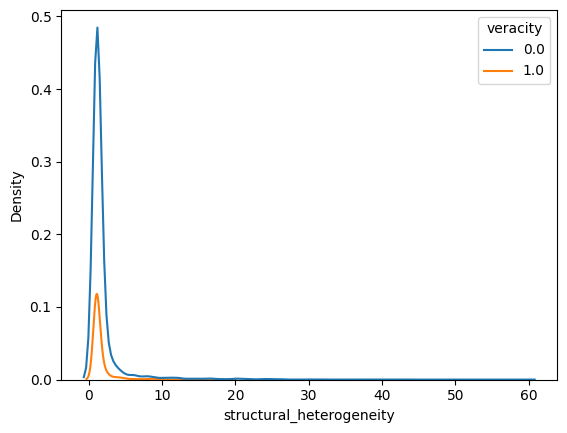

In [21]:
import seaborn as sns

sns.kdeplot(data=X_test, x="structural_heterogeneity", hue=y_test)

<Axes: xlabel='structural_heterogeneity', ylabel='Density'>

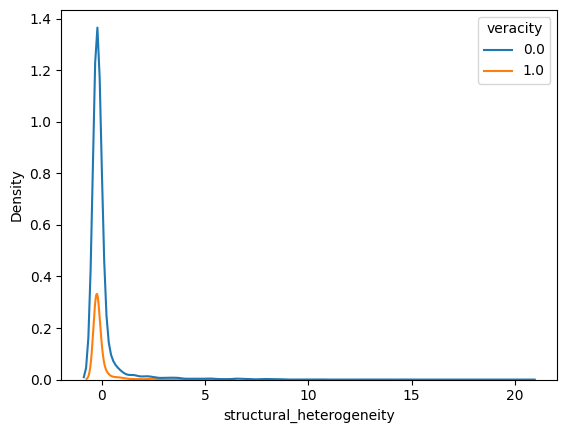

In [23]:
import seaborn as sns

sns.kdeplot(data=scaled_X_test, x="structural_heterogeneity", hue=y_test)

In [28]:
scaled_X_test['structural_heterogeneity'].describe()

count    5702.000000
mean        0.023117
std         1.011128
min        -0.280846
25%        -0.280846
50%        -0.238931
75%        -0.120205
max        20.367383
Name: structural_heterogeneity, dtype: float64

In [11]:
# accuracy, precision, recall, balanced_accuracy, fbeta, avg_precision, roc_auc
import joblib
from sklearn.ensemble import RandomForestClassifier

model = joblib.load('./rf.joblib')
# model = gcv.best_estimator_
a = test_model_with_x_test(model)
b = test_model_with_scaled_test(model)
print(a)
print(b)

ValueError: Classification metrics can't handle a mix of unknown and binary targets

In [10]:
y_test.value_counts()

veracity
0.0    4782
1.0     920
Name: count, dtype: int64

In [12]:
model = joblib.load('./xgb.joblib')

a = test_model_with_x_test(model)
b = test_model_with_scaled_test(model)
print(a)
print(b)

c:\Program Files\Python312\Lib\site-packages\xgboost\core.py:160: UserWarning: [16:32:50] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0750514818a16474a-1\xgboost\xgboost-ci-windows\src\common/error_msg.h:80: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  warnings.warn(smsg, UserWarning)


ValueError: Classification metrics can't handle a mix of unknown and binary targets

In [21]:
print_confusion_matrix(model, scaled=False)
print_confusion_matrix(model, scaled=True)

[[   2 4780]
 [   0  920]]
[[4781    1]
 [ 920    0]]


In [18]:
y_test.value_counts()

veracity
0.00000    4782
1.00000     920
Name: count, dtype: int64

In [9]:
scaled_X_test.describe() 

,depth,size,max_breadth,virality,strongly_cc,size_of_scc,density,layer_ratio,structural_heterogeneity,characteristic_distance
count,5702.000000,5702.000000,5702.000000,5702.000000,5702.000000,5702.000000,5702.000000,5702.000000,5702.000000,5702.000000
mean,0.006187,0.025153,0.027326,-0.024235,0.025153,0.004811,-0.013907,-0.018160,0.023117,0.005230
std,1.015982,1.031864,1.035087,0.997767,1.031864,0.961629,1.007293,0.896065,1.011128,0.993886
min,-0.707413,-0.778667,-0.737187,-1.632427,-0.778667,-0.094962,-1.501917,-0.420607,-0.280846,-2.372612
25%,-0.707413,-0.778667,-0.737187,-0.875674,-0.778667,-0.094962,-0.945413,-0.420607,-0.280846,-0.396590
50%,-0.707413,-0.306361,-0.439656,0.133845,-0.306361,-0.092932,-0.110440,-0.420607,-0.238931,-0.396590
75%,0.622069,0.317993,0.280079,1.017175,0.317993,-0.086842,1.281183,0.074803,-0.120205,0.339473
max,5.388213,5.938840,6.057111,2.851782,5.938840,38.719261,1.281183,17.457229,20.367383,8.909475


In [10]:
X_test.describe() 

,depth,size,max_breadth,virality,strongly_cc,size_of_scc,density,layer_ratio,structural_heterogeneity,characteristic_distance
count,5702.000000,5702.000000,5702.000000,5702.000000,5702.000000,5702.000000,5702.000000,5702.000000,5702.000000,5702.000000
mean,1.728341,100.292178,62.204490,0.303507,100.292178,100.292178,0.267342,1.162470,1.855967,2.511423
std,1.388567,947.353274,481.991423,0.188259,947.353274,947.353274,0.180957,0.361747,2.847359,4.606881
min,1.000000,2.000000,2.000000,0.000073,2.000000,2.000000,0.000026,1.000000,1.000000,0.000000
25%,1.000000,2.000000,2.000000,0.142857,2.000000,2.000000,0.100000,1.000000,1.000000,1.439579
50%,1.000000,4.000000,3.000000,0.333333,4.000000,4.000000,0.250000,1.000000,1.118034,1.439579
75%,2.000000,10.000000,8.000000,0.500000,10.000000,10.000000,0.500000,1.200000,1.452369,2.466303
max,24.000000,38240.000000,20998.000000,0.846154,38240.000000,38240.000000,0.500000,8.217391,59.145880,249.999966


In [13]:
pd.set_option('display.float_format', lambda x: '%.5f' % x)
X_train_val.describe() 

,depth,size,max_breadth,virality,strongly_cc,size_of_scc,density,layer_ratio,structural_heterogeneity,characteristic_distance
count,32305.00000,32305.00000,32305.00000,32305.00000,32305.00000,32305.00000,32305.00000,32305.00000,32305.00000,32305.00000
mean,1.71094,95.55236,60.10339,0.30808,95.55236,95.55236,0.26984,1.16980,1.79087,409696.38828
std,1.31975,985.16958,550.74037,0.18868,985.16958,985.16958,0.17965,0.40371,2.81607,73636717.05376
min,1.00000,2.00000,2.00000,0.00004,2.00000,2.00000,0.00002,1.00000,1.00000,0.00000
25%,1.00000,2.00000,2.00000,0.14286,2.00000,2.00000,0.11111,1.00000,1.00000,1.43958
50%,1.00000,4.00000,3.00000,0.33333,4.00000,4.00000,0.25000,1.00000,1.10657,1.43958
75%,2.00000,9.00000,8.00000,0.50000,9.00000,9.00000,0.50000,1.21963,1.42887,2.46630
max,19.00000,46895.00000,29527.00000,1.02778,46895.00000,46895.00000,0.50000,13.00000,78.89904,13235162895.68282


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
total_cv = 5
random_state = 7
no_of_active_features = 15
optimization_metric = "average_precision_score"

# logit_grid = {
#     "penalty": ["l2", "l1"],
# }
logit_grid = {
    "penalty": ["l1", "l2", "elasticnet"]
}
logit_model = LogisticRegression()

clf = GridSearchCV(
    estimator=logit_model,
    cv=total_cv,
    refit=optimization_metric,
    param_grid=logit_grid,
    scoring=scorers_for_gridcv,
    verbose=0,
    n_jobs=-1,
)

logit_result = clf.fit(X_train_val, y_train_val)

# if logit_result != None:
#     process_gridcv_results(logit_result.cv_results_, "logit")


C:\Users\istiyak\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
10 fits failed out of a total of 15.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\istiyak\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\istiyak\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py", line 1152, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\istiyak\AppData\Roaming\Python\Python312

In [13]:
joblib.dump(logit_result, "logit.joblib")

b = joblib.load('logit.joblib')
b.best_estimator_

LogisticRegression()

In [9]:
temp = logit_result.cv_results_
d = pd.DataFrame.from_dict(temp)
d.sort_values(by="rank_test_average_precision_score", ascending=True)['mean_test_accuracy_score'].iloc[0]

0.838136511375948

In [13]:
cv_result = logit_result.cv_results_
cv_result_df = pd.DataFrame.from_dict(cv_result)
cv_result_df.sort_values(by="rank_test_average_precision_score", ascending=True, inplace=True)
mean_test_accuracy_score = round(cv_result_df['mean_test_accuracy_score'].iloc[0], 2)
mean_test_precision_0 = round(cv_result_df['mean_test_precision_0'].iloc[0], 2)
mean_test_precision_1 = round(cv_result_df['mean_test_precision_1'].iloc[0], 2)
mean_test_recall_0 = round(cv_result_df['mean_test_recall_0'].iloc[0], 2)
mean_test_recall_1 = round(cv_result_df['mean_test_recall_1'].iloc[0], 2)
mean_test_fbeta_score = round(cv_result_df['mean_test_fbeta_score'].iloc[0], 2)
mean_test_balanced_accuracy_score = round(cv_result_df['mean_test_balanced_accuracy_score'].iloc[0], 2)
mean_test_average_precision_score = round(cv_result_df['mean_test_average_precision_score'].iloc[0], 2)
mean_test_roc_auc = round(cv_result_df['mean_test_roc_auc'].iloc[0], 2)
print(mean_test_accuracy_score, mean_test_precision_0, mean_test_precision_1, mean_test_recall_0, mean_test_recall_1, mean_test_fbeta_score, mean_test_balanced_accuracy_score, mean_test_average_precision_score, mean_test_roc_auc)

0.84 0.84 0.0 1.0 0.0 0.0 0.5 0.16 0.5


In [14]:
import wandb
import os 

os.environ["WANDB_API_KEY"] = "b21f4406f3966154b12e98de3bef934216952a54"
os.environ["WANDB_ENTITY"] = "istiyaksiddiquee"
os.environ["WANDB__SERVICE_WAIT"] = "300"


wandb.init(project='RQ2RUN7', group='logit', job_type='epoch_5')
wandb.log({
    "test_accuracy": 5.0, 
})

wandb.finish()

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: istiyaksiddiquee. Use `wandb login --relogin` to force relogin


test_accuracy,▁
test_accuracy,5.0


In [25]:
logit_result.best_score_
logit_result.best_estimator_

0.16186348862405203

In [5]:
# this piece of code will download the models from wandb 
# for a particular project and then renames the folder accordingly
# please avoid running this code all the time to avoid confusion

import os
import wandb

os.environ["WANDB_API_KEY"] = "b21f4406f3966154b12e98de3bef934216952a54"
os.environ["WANDB_ENTITY"] = "istiyaksiddiquee"

wandb_project = "RQ4Final1"

run = wandb.init(project=wandb_project)

artifact = run.use_artifact(wandb_project + "/Logistic-Model:latest")
model_dir = artifact.download()

artifact = run.use_artifact(wandb_project + "/DT-Model:latest")
model_dir = artifact.download()

artifact = run.use_artifact(wandb_project + "/RF-Model:latest")
model_dir = artifact.download()

artifact = run.use_artifact(wandb_project + "/XGB-Model:latest")
model_dir = artifact.download()

artifact = run.use_artifact(wandb_project + "/LGB-Model:latest")
model_dir = artifact.download()

artifact = run.use_artifact(wandb_project + "/Default-RF-Cls:latest")
model_dir = artifact.download()

artifact = run.use_artifact(wandb_project + "/Stratified-Dummy-Cls:latest")
model_dir = artifact.download()

artifact = run.use_artifact(wandb_project + "/Most-Freq-Dummy-Cls:latest")
model_dir = artifact.download()

run.finish()

os.rename('artifacts', wandb_project)

wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


In [1]:
from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score,
    average_precision_score,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from copy import copy

def get_all_scores(y_real, y_pred, y_scores):
    accuracy = accuracy_score(y_real, y_pred)
    precision = precision_score(y_real, y_pred, average=None)
    recall = recall_score(y_real, y_pred, average=None)
    balanced_accuracy = balanced_accuracy_score(y_real, y_pred)
    fbeta = fbeta_score(y_real, y_pred, beta=0.5)
    avg_precision = average_precision_score(y_real, y_scores)
    roc_auc = roc_auc_score(y_real, y_scores)

    return {
        "average_precision": round(avg_precision, 2), 
        "precision_0": round(precision[0], 2), 
        "precision_1": round(precision[1], 2), 
        "recall_0": round(recall[0], 2), 
        "recall_1": round(recall[1], 2), 
        "roc_auc": round(roc_auc, 2),
        "balanced_accuracy": round(balanced_accuracy, 2),
        "fbeta": round(fbeta, 2), 
        "accuracy": round(accuracy, 2), 
    }

def flip_true_false(y):
    copy_y = copy(y)
    flipped_y = [0 if item == 1 else 1 for item in copy_y]
    return flipped_y

def test_model(model, scaled_X_test_df, y_test):
    y_pred = model.predict(scaled_X_test_df)
    y_pred_proba = model.predict_proba(scaled_X_test_df)
    
    return get_all_scores(y_test, y_pred, y_pred_proba[:, 1])

    # flipped_y = flip_true_false(y_pred)
    # print(get_all_scores(y_test, flipped_y, y_pred_proba[:, 0]))
    

In [4]:
# accuracy, precision, recall, balanced_accuracy, fbeta, avg_precision, roc_auc
import joblib
import pandas as pd

def performance_testing(project, scaled_X_test_df, y_test):

    logit_model = joblib.load(f'./{project}/Logistic-Model-v0/logit.joblib')
    logit_scores = test_model(logit_model, scaled_X_test_df, y_test)
    logit_predict_proba = logit_model.predict_proba(scaled_X_test_df)

    dt_model = joblib.load(f'./{project}/DT-Model-v0/dt.joblib')
    dt_scores = test_model(dt_model, scaled_X_test_df, y_test)
    dt_predict_proba = dt_model.predict_proba(scaled_X_test_df)

    rf_model = joblib.load(f'./{project}/RF-Model-v0/rf.joblib')
    rf_scores = test_model(rf_model, scaled_X_test_df, y_test)
    rf_predict_proba = rf_model.predict_proba(scaled_X_test_df)

    xgb_model = joblib.load(f'./{project}/XGB-Model-v0/xgb.joblib')
    xgb_scores = test_model(xgb_model, scaled_X_test_df, y_test)
    xgb_predict_proba = xgb_model.predict_proba(scaled_X_test_df)

    lgb_model = joblib.load(f'./{project}/LGB-Model-v0/lgb.joblib')
    lgb_scores = test_model(lgb_model, scaled_X_test_df, y_test)
    lgb_predict_proba = lgb_model.predict_proba(scaled_X_test_df)

    default_rf_model = joblib.load(f'./{project}/Default-RF-Cls-v0/default_rf.joblib')
    default_rf_scores = test_model(default_rf_model, scaled_X_test_df, y_test)
    default_rf_predict_proba = default_rf_model.predict_proba(scaled_X_test_df)

    freq_dummy_model = joblib.load(f'./{project}/Most-Freq-Dummy-Cls-v0/most_freq_dummy_cls.joblib')
    freq_dummy_scores = test_model(freq_dummy_model, scaled_X_test_df, y_test)
    freq_dummy_predict_proba = freq_dummy_model.predict_proba(scaled_X_test_df)

    stratified_dummy_model = joblib.load(f'./{project}/Stratified-Dummy-Cls-v0/stratified_dummy_cls.joblib')
    stratified_dummy_scores = test_model(stratified_dummy_model, scaled_X_test_df, y_test)
    stratified_dummy_predict_proba = stratified_dummy_model.predict_proba(scaled_X_test_df)

    result_df = pd.DataFrame(
        [
        logit_scores, dt_scores, rf_scores, xgb_scores, lgb_scores, freq_dummy_scores, stratified_dummy_scores
        ],
        index=['logit_scores', 'dt_scores', 'rf_scores', 'xgb_scores', 'lgb_scores', 'freq_dummy_scores', 'stratified_dummy_scores']
    )

    # return result_df.sort_values(by='average_precision', ascending=False)
    return result_df

In [110]:
from copy import copy
import pickle
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer

def read_pickled_data(dataset, feature_selection):

    prefix = f'../../datasets-for-exp/{dataset}/{dataset}_'

    with open(prefix + 'x_train_val.pickle', "rb") as file:
        X_train_val = pickle.load(file)

    with open(prefix + 'y_train_val.pickle' , "rb") as file:
        y_train_val = pickle.load(file)

    with open(prefix + 'x_test.pickle',  "rb") as file:
        X_test = pickle.load(file)

    with open(prefix + 'y_test.pickle',  "rb") as file:
        y_test = pickle.load(file)

    class CustomFunctionTransformer(FunctionTransformer):
        def get_feature_names_out(self, input_features=None):
            return input_features

    log_norm_custom = CustomFunctionTransformer(func=np.log)

    # depth, size, max_breadth, virality, density, layer_ratio, structural_heterogeneity, characteristic_distance

    quant = True
    # feature_selection = 0
    dropped_columns = ['size', 'max_breadth', 'virality']
    normalization_columns = ['size', 'max_breadth', 'characteristic_distance']

    original_column_order = ['scale__depth', 'log_norm__size', 'log_norm__max_breadth',
        'scale__virality', 'scale__density', 'scale__layer_ratio',  'scale__structural_heterogeneity', 
        'log_norm__characteristic_distance' ]   

    if feature_selection == 1:
        for item in dropped_columns:
            
            if item in normalization_columns:
                original_column_order.remove('log_norm__'+item)
            else:
                original_column_order.remove('scale__' + item)
                
        normalization_columns = list(set(normalization_columns)-set(dropped_columns))


    if feature_selection == 1:
        X_train_val.drop(dropped_columns, axis=1, inplace=True)
        X_test.drop(dropped_columns, axis=1, inplace=True)
    
    normalized_df = copy(X_train_val)
    
    scaler = StandardScaler()

    preprocessor = ColumnTransformer([
        ('log_norm', log_norm_custom, normalization_columns),  # Columns to log-normalize
        ('scale', scaler, list(set(list(X_train_val.columns)) - set(normalization_columns)))  # Columns to scale
    ])

    if quant == True:
        cd_first_quantile = np.quantile(normalized_df["characteristic_distance"], 0.25)
        cd_third_quantile = np.quantile(normalized_df["characteristic_distance"], 0.75)
        normalized_df["characteristic_distance"] = normalized_df["characteristic_distance"] + cd_first_quantile**2 / cd_third_quantile
        
        test_cd_first_quantile = np.quantile(X_test["characteristic_distance"], 0.25)
        test_cd_third_quantile = np.quantile(X_test["characteristic_distance"], 0.75)
        X_test["characteristic_distance"] = X_test["characteristic_distance"] + test_cd_first_quantile**2 / test_cd_third_quantile
        
    scaled_X_train_val = preprocessor.fit_transform(normalized_df)
    scaled_X_test = preprocessor.transform(X_test)

    transformed_columns = preprocessor.get_feature_names_out()
    
    scaled_X_train_val_df = pd.DataFrame(scaled_X_train_val, columns=transformed_columns)
    scaled_X_test_df = pd.DataFrame(scaled_X_test, columns=transformed_columns)

    scaled_X_train_val_df =  scaled_X_train_val_df[original_column_order]
    scaled_X_test_df =  scaled_X_test_df[original_column_order]

    return scaled_X_train_val_df, y_train_val, scaled_X_test_df, y_test


In [111]:
scaled_X_train_val, y_train_val, scaled_X_test, y_test = read_pickled_data(dataset = "RQ3Final3", feature_selection = 1)
print(scaled_X_train_val.shape, y_train_val.shape, scaled_X_test.shape, y_test.shape)

(1049, 5) (1049,) (117, 5) (117,)


In [104]:
dict = {}
for i in range(5, 9):
    feature_selection = 1
    if i%2 == 0:
        feature_selection = 0
    project = 'RQ2Comb'+str(i)
    print(f"project = {project}, feature_selection = {feature_selection}")
    scaled_X_train_val, y_train_val, scaled_X_test, y_test = read_pickled_data(dataset = "RQ2Final2", feature_selection = feature_selection)
    print(scaled_X_train_val.shape, y_train_val.shape, scaled_X_test.shape, y_test.shape)
    result_df = performance_testing(project = project, scaled_X_test_df=scaled_X_test, y_test=y_test)
    
    dict[project] = list(result_df['average_precision'].values)


project = RQ2Comb5, feature_selection = 1
(1270, 6) (1270,) (142, 6) (142,)
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_gain_to_split is set=0.1, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.1
[LightGBM] [Warning] lambda_l2 is set=10, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_gain_to_split is set=0.1, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.1
[LightGBM] [Warning] lambda_l2 is set=10, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_gain_to_split is set=0.1, min_split_gain=0.0 will be ignored. Current value: min_

In [103]:
result_df

,average_precision,precision_0,precision_1,recall_0,recall_1,roc_auc,balanced_accuracy,fbeta,accuracy
logit_scores,0.20,0.78,0.00,1.00,0.00,0.45,0.50,0.00,0.78
dt_scores,0.22,0.78,0.00,1.00,0.00,0.50,0.50,0.00,0.78
rf_scores,0.24,0.78,0.00,1.00,0.00,0.55,0.50,0.00,0.78
xgb_scores,0.22,0.78,0.00,1.00,0.00,0.50,0.50,0.00,0.78
lgb_scores,0.25,0.78,0.00,1.00,0.00,0.52,0.50,0.00,0.78
freq_dummy_scores,0.22,0.78,0.00,1.00,0.00,0.50,0.50,0.00,0.78
stratified_dummy_scores,0.22,0.76,0.15,0.74,0.16,0.51,0.45,0.15,0.61


In [105]:
import numpy as np
result_array = []
for item in dict.keys():
    for k in dict[item]:
        result_array.append(k)
print(result_array)

[0.21, 0.24, 0.23, 0.22, 0.25, 0.22, 0.2, 0.22, 0.24, 0.23, 0.22, 0.26, 0.22, 0.22, 0.22, 0.22, 0.23, 0.21, 0.25, 0.22, 0.27, 0.2, 0.22, 0.24, 0.22, 0.25, 0.22, 0.21]


In [102]:
feature_array = [
    'Feature1', 'Feature1', 'Feature1', 'Feature1', 'Feature1', 'Feature1', 'Feature1',
    'Feature0', 'Feature0', 'Feature0', 'Feature0', 'Feature0', 'Feature0', 'Feature0', 
    'Feature1', 'Feature1', 'Feature1', 'Feature1', 'Feature1', 'Feature1', 'Feature1',
    'Feature0', 'Feature0', 'Feature0', 'Feature0', 'Feature0', 'Feature0', 'Feature0',
]
smote_array = [
    'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 
    'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 
    'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 
    'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 
]

import numpy as np
result_array = []
for item in dict.keys():
    for k in dict[item]:
        result_array.append(k)

print(np.array(result_array).std(), np.array(result_array).var())

srh_df = pd.DataFrame({
    'feature_state': feature_array,
    'smote_state': smote_array,
    'result': result_array
})

print(result_array)

0.014603605928757766 0.00021326530612244895
[0.21, 0.24, 0.23, 0.22, 0.25, 0.22, 0.25, 0.22, 0.24, 0.23, 0.22, 0.26, 0.22, 0.22, 0.22, 0.22, 0.23, 0.21, 0.25, 0.22, 0.21, 0.2, 0.22, 0.24, 0.22, 0.25, 0.22, 0.22]


In [97]:
srh_df['rank'] = srh_df.result.sort_values().rank(numeric_only = float)

rows = srh_df.groupby(['feature_state'], as_index = False).agg({'rank':['count', 'mean', 'var']}).rename(columns={'rank':'row'})
rows.columns = ['_'.join(col) for col in rows.columns]
rows.columns = rows.columns.str.replace(r'_$',"")
rows['row_mean_rows'] = rows.row_mean.mean()
rows['sqdev'] = (rows.row_mean - rows.row_mean_rows)**2

cols = srh_df.groupby(['smote_state'], as_index = False).agg({'rank':['count', 'mean', 'var']}).rename(columns={'rank':'col'})
cols.columns = ['_'.join(col) for col in cols.columns]
cols.columns = cols.columns.str.replace(r'_$',"")
cols['col_mean_cols'] = cols.col_mean.mean()
cols['sqdev'] = (cols.col_mean-cols.col_mean_cols)**2

data_sum         = srh_df.groupby(['feature_state', 'smote_state'], as_index = False).agg({'rank':['count', 'mean', 'var']})
data_sum.columns = ['_'.join(col) for col in data_sum.columns]
data_sum.columns = data_sum.columns.str.replace(r'_$',"")

nobs_row   = rows.row_count.mean()
nobs_total = rows.row_count.sum()
nobs_col   = cols.col_count.mean()

Columns_SS = cols.sqdev.sum()*nobs_col
Rows_SS    = rows.sqdev.sum()*nobs_row
Within_SS  = data_sum.rank_var.sum()*(data_sum.rank_count.min()-1)
MS         = srh_df['rank'].var()
TOTAL_SS   = MS * (nobs_total-1)
Inter_SS   = TOTAL_SS - Within_SS - Rows_SS - Columns_SS

H_rows = Rows_SS/MS
H_cols = Columns_SS/MS
H_int  = Inter_SS/MS

df_rows   = len(rows)-1
df_cols   = len(cols)-1
df_int    = df_rows*df_cols
df_total  = len(srh_df)-1
df_within = df_total - df_int - df_cols - df_rows

from scipy import stats
p_rows  = round(1-stats.chi2.cdf(H_rows, df_rows),4)
p_cols  = round(1-stats.chi2.cdf(H_cols, df_cols),4)
p_inter = round(1-stats.chi2.cdf(H_int, df_int),4)

print(round(H_rows, 2), round(H_cols, 2), round(H_int, 2 ))
print(p_rows, p_cols, p_inter)

0.04 0.46 0.46
0.8459 0.4964 0.4964


0.2963 0.794 0.5216


In [ ]:
# install.packages("rcompanion")
# install.packages("FSA")

# feature_array = c('Feature1', 'Feature1', 'Feature1', 'Feature1', 'Feature1', 'Feature1', 'Feature1','Feature0', 'Feature0', 'Feature0', 'Feature0', 'Feature0', 'Feature0', 'Feature0', 'Feature1', 'Feature1', 'Feature1', 'Feature1', 'Feature1', 'Feature1', 'Feature1', 'Feature0', 'Feature0', 'Feature0', 'Feature0', 'Feature0', 'Feature0', 'Feature0')
# smote_array = c('SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1', 'SMOTE1',  'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0', 'SMOTE0')

# result_array = c(0.19, 0.21, 0.29, 0.21, 0.25, 0.22, 0.22, 0.19, 0.26, 0.31, 0.22, 0.27, 0.22, 0.23, 0.2, 0.22, 0.23, 0.21, 0.3, 0.22, 0.22, 0.2, 0.22, 0.23, 0.22, 0.31, 0.22, 0.22)

# Data = data.frame(feature_array, smote_array, result_array)

# library(rcompanion)

# scheirerRayHare(result_array ~ feature_array + smote_array, data = Data)

In [23]:
# RQ2Comb3
result_df[['average_precision']]

,average_precision
default_rf_scores,0.19
logit_scores,0.18
rf_scores,0.18
lgb_scores,0.18
dt_scores,0.16
xgb_scores,0.16
freq_dummy_scores,0.16
stratified_dummy_scores,0.16


In [30]:
# RQ2Comb4
result_df[['average_precision']]

,average_precision
lgb_scores,0.19
default_rf_scores,0.19
logit_scores,0.18
rf_scores,0.18
dt_scores,0.16
xgb_scores,0.16
freq_dummy_scores,0.16
stratified_dummy_scores,0.16


In [ ]:
default_rf_scores	0.19
logit_scores	0.18
lgb_scores	0.18
rf_scores	0.17
dt_scores	0.16
xgb_scores	0.16
freq_dummy_scores	0.16
stratified_dummy_scores	0.16

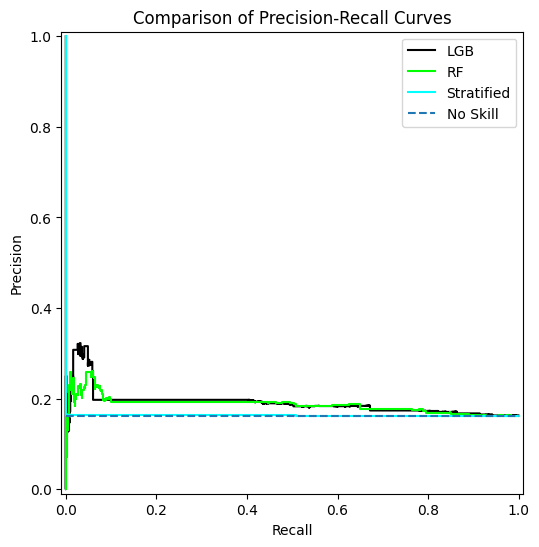

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay

label = 1

lgb_precision, lgb_recall, _ = precision_recall_curve(y_test, lgb_predict_proba[:, label])
xgb_precision, xgb_recall, _ = precision_recall_curve(y_test, xgb_predict_proba[:, label])
rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_predict_proba[:, label])
logit_precision, logit_recall, _ = precision_recall_curve(y_test, logit_predict_proba[:, label])
dt_precision, dt_recall, _ = precision_recall_curve(y_test, dt_predict_proba[:, label])
most_freq_precision, most_freq_recall, _ = precision_recall_curve(y_test, freq_dummy_predict_proba[:, label])
stratified_precision, stratified_recall, _ = precision_recall_curve(y_test, stratified_dummy_predict_proba[:, label])

no_skill = len(y_test[y_test==label]) / len(y_test)

colors = ['black', 'red', 'lime', 'dodgerblue', 'yellow', 'navy', 'cyan']

# Plot each model's Precision-Recall curve on the same axes
plt.figure(figsize=(8, 6))
lgb_display = PrecisionRecallDisplay(precision=lgb_precision, recall=lgb_recall)
lgb_display.plot(label="LGB", color=colors[0], ax=plt.gca())  # plt.gca() gets current axes

# xgb_display = PrecisionRecallDisplay(precision=xgb_precision, recall=xgb_recall)
# xgb_display.plot(label="XGB", color=colors[1], ax=plt.gca())  # plt.gca() gets current axes

rf_display = PrecisionRecallDisplay(precision=rf_precision, recall=rf_recall)
rf_display.plot(label="RF", color=colors[2], ax=plt.gca())  # plt.gca() gets current axes

# logit_display = PrecisionRecallDisplay(precision=logit_precision, recall=logit_recall)
# logit_display.plot(label="Logit", color=colors[3], ax=plt.gca())  # plt.gca() gets current axes

# dt_display = PrecisionRecallDisplay(precision=dt_precision, recall=dt_recall)
# dt_display.plot(label="DT", color=colors[4], ax=plt.gca())  # plt.gca() gets current axes

# freq_display = PrecisionRecallDisplay(precision=most_freq_precision, recall=most_freq_recall)
# freq_display.plot(label="Most Frequent", color=colors[5], ax=plt.gca())  # plt.gca() gets current axes

stratified_display = PrecisionRecallDisplay(precision=stratified_precision, recall=stratified_recall)
stratified_display.plot(label="Stratified", color=colors[6], ax=plt.gca())  # plt.gca() gets current axes

plt.gca().plot([0, 1], [no_skill, no_skill], linestyle='--', label='No Skill')

# Add labels and legend
plt.title("Comparison of Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()


In [23]:
scaled_X_train_val.columns

Index(['depth', 'size', 'max_breadth', 'density', 'layer_ratio',
       'structural_heterogeneity', 'characteristic_distance'],
      dtype='object')

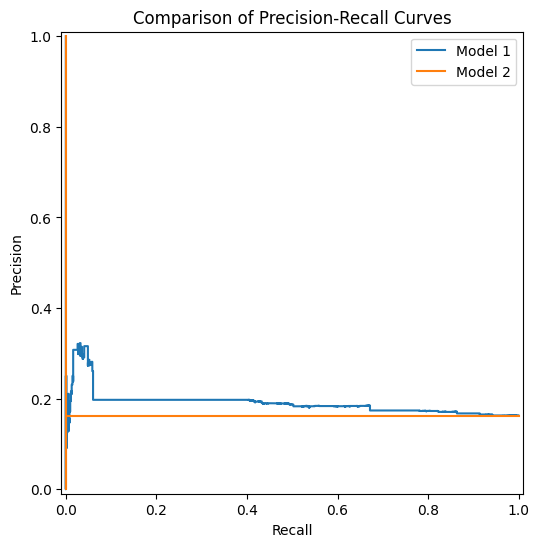

In [12]:
from sklearn.metrics import PrecisionRecallDisplay, precision_recall_curve
import matplotlib.pyplot as plt



# Calculate precision-recall for each model
precision1, recall1, _ = precision_recall_curve(y_test, lgb_predict_proba[:, 1])
precision2, recall2, _ = precision_recall_curve(y_test, xgb_predict_proba[:, 1])

# Plot each model's Precision-Recall curve on the same axes
plt.figure(figsize=(8, 6))
display1 = PrecisionRecallDisplay(precision=precision1, recall=recall1)
display1.plot(label="Model 1", ax=plt.gca())  # plt.gca() gets current axes

display2 = PrecisionRecallDisplay(precision=precision2, recall=recall2)
display2.plot(label="Model 2", ax=plt.gca())

# Add labels and legend
plt.title("Comparison of Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()


In [30]:
scaled_X_train_val.columns

Index(['depth', 'size', 'max_breadth', 'density', 'layer_ratio',
       'structural_heterogeneity', 'characteristic_distance'],
      dtype='object')

array([[<Axes: xlabel='scale__depth', ylabel='ALE'>,
        <Axes: xlabel='log_norm__size', ylabel='ALE'>,
        <Axes: xlabel='scale__virality', ylabel='ALE'>,
        <Axes: xlabel='scale__density', ylabel='ALE'>],
       [<Axes: xlabel='scale__layer_ratio', ylabel='ALE'>,
        <Axes: xlabel='scale__structural_heterogeneity', ylabel='ALE'>,
        <Axes: xlabel='log_norm__characteristic_distance', ylabel='ALE'>,
        None]], dtype=object)

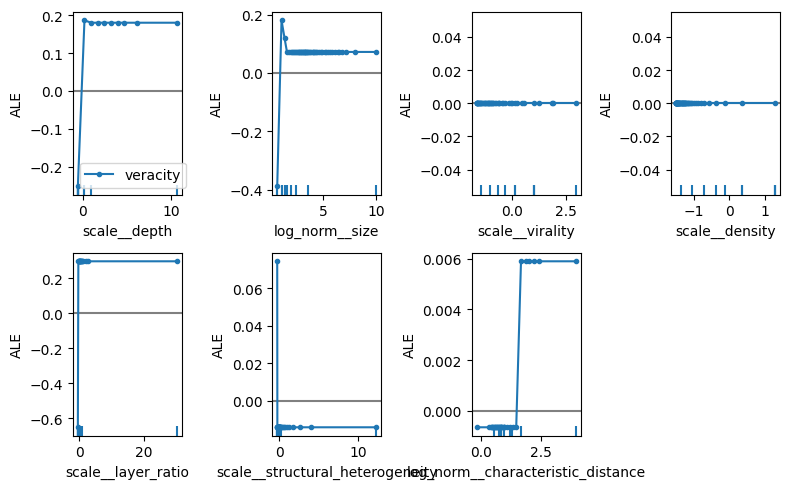

In [14]:
from alibi.explainers import ALE, plot_ale

logit_fun_lr = xgb_model.predict
proba_fun_lr = xgb_model.predict_proba

logit_ale_lr = ALE(logit_fun_lr, feature_names=list(scaled_X_test_df.columns), target_names=['veracity'])
proba_ale_lr = ALE(proba_fun_lr, feature_names=list(scaled_X_test_df.columns), target_names=['veracity'])

logit_exp_lr = logit_ale_lr.explain(scaled_X_test_df.values)
proba_exp_lr = proba_ale_lr.explain(scaled_X_test_df.values)

plot_ale(logit_exp_lr, n_cols=4, fig_kw={'figwidth': 8, 'figheight': 5}, sharey=None)

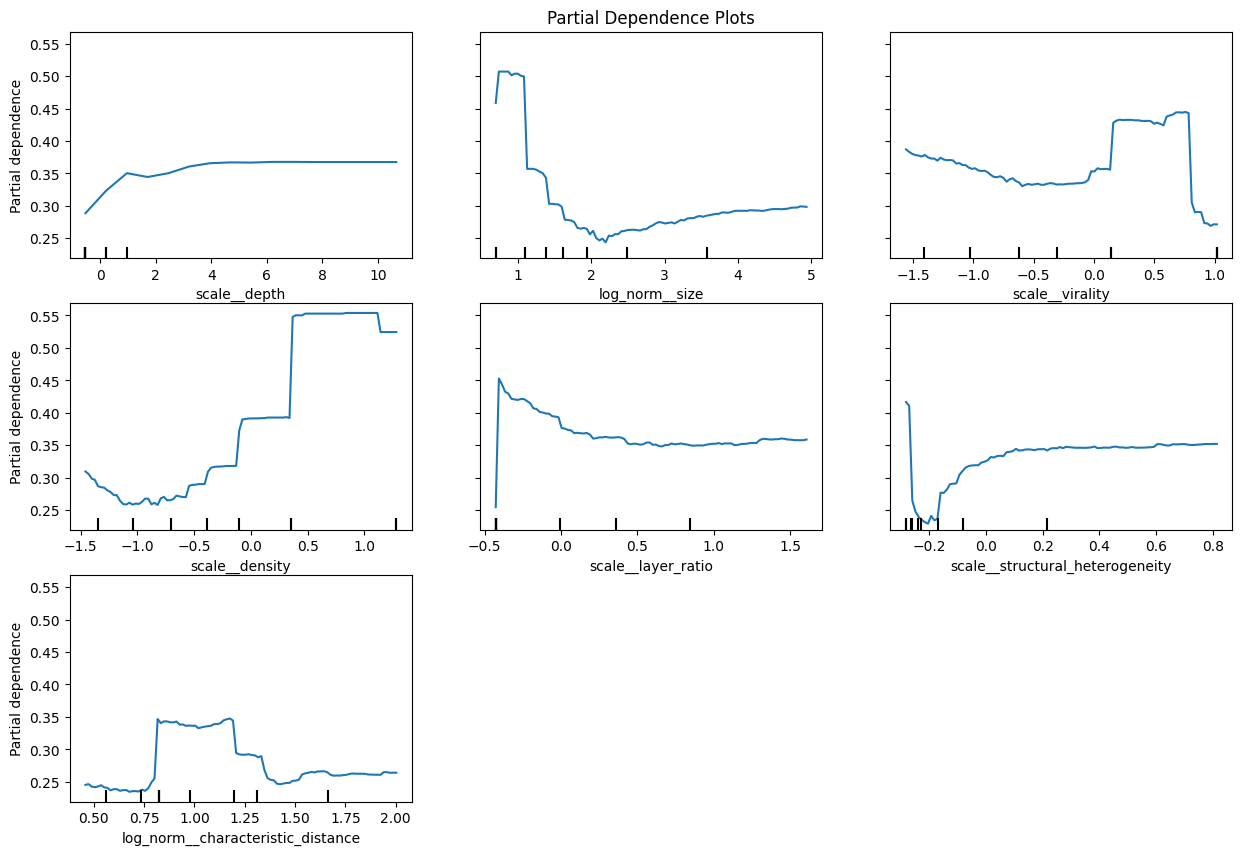

In [20]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(15, 10))
ax.set_title("Partial Dependence Plots")
PartialDependenceDisplay.from_estimator(
    estimator=rf_model,
    X=scaled_X_test_df,
    features=list(scaled_X_test_df.columns), # the features to plot
    random_state=5,
    ax=ax,
)
plt.show()

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


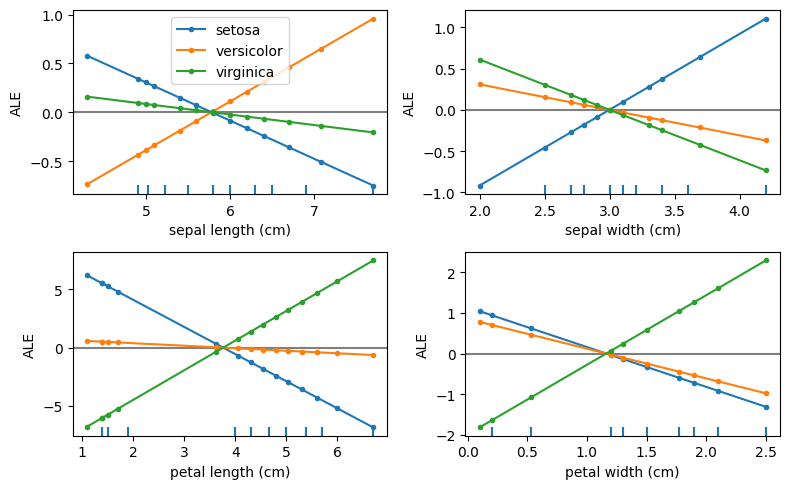

In [20]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from alibi.explainers import ALE, plot_ale

data = load_iris()
feature_names = data.feature_names
target_names = data.target_names
X = data.data
y = data.target
print(feature_names)
print(target_names)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)

logit_fun_lr = lr.decision_function
proba_fun_lr = lr.predict_proba

logit_ale_lr = ALE(logit_fun_lr, feature_names=feature_names, target_names=target_names)
proba_ale_lr = ALE(proba_fun_lr, feature_names=feature_names, target_names=target_names)

logit_exp_lr = logit_ale_lr.explain(X_train)
proba_exp_lr = proba_ale_lr.explain(X_train)

plot_ale(logit_exp_lr, n_cols=2, fig_kw={'figwidth': 8, 'figheight': 5}, sharey=None);

ExactExplainer explainer: 3802it [07:35,  8.14it/s]                          


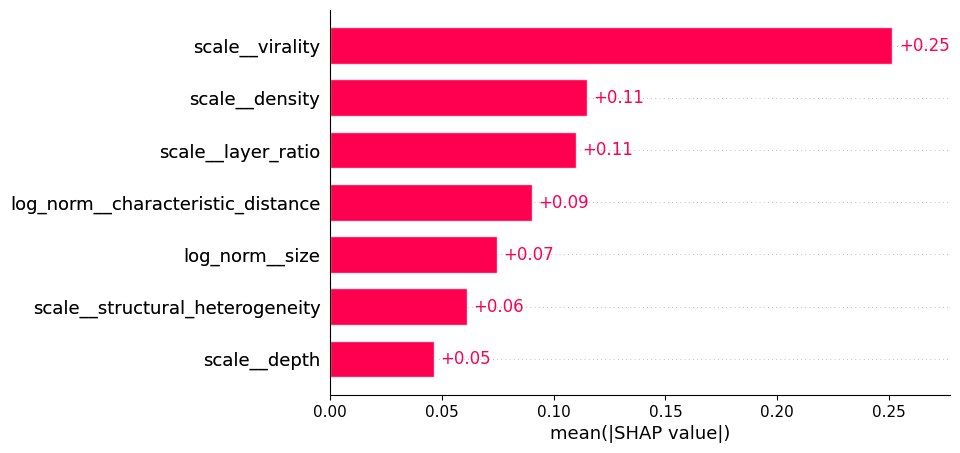

In [19]:
import shap
explainer = shap.Explainer(rf_model.predict, scaled_X_test_df)
# Calculates the SHAP values - It takes some time
shap_values = explainer(scaled_X_test_df)
shap.plots.bar(shap_values)

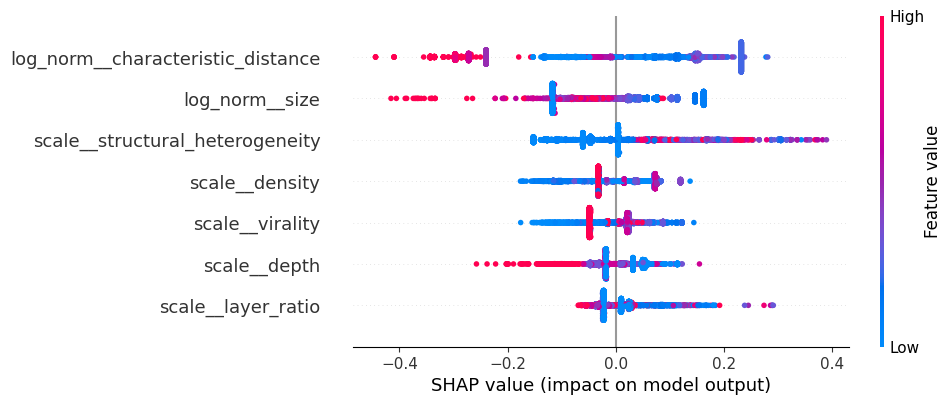

In [18]:
shap.plots.beeswarm(shap_values)

In [14]:
import numpy as np
from scipy.stats import chi2

def rank_data_with_tie_handling(data):
    """
    Ranks data within each block (experiment) while handling ties.
    
    Parameters:
    - data (3D NumPy Array): Experiments × Algorithms × Configurations
    
    Returns:
    - ranked_data (3D NumPy Array): Ranked data with tie handling
    """
    ranked_data = np.zeros(data.shape)
    for exp_idx in range(data.shape[0]):  # Loop through each experiment
        exp_data = data[exp_idx, :, :].flatten()  # Flatten algorithms and configurations
        sorted_indices = np.argsort(-exp_data)  # Sort in descending order
        ranks = np.zeros_like(exp_data)
        
        # Handle ties by assigning the average of tied ranks
        current_rank = 1
        for idx in sorted_indices:
            if np.sum(exp_data[idx] == exp_data[sorted_indices[:sorted_indices.tolist().index(idx)]]) > 0:
                # If this is a tied value, find all tied values and assign average rank
                tied_mask = exp_data == exp_data[idx]
                num_ties = np.sum(tied_mask)
                tied_rank = (current_rank + (current_rank + num_ties - 1)) / 2
                ranks[tied_mask] = tied_rank
                current_rank += num_ties
            else:
                ranks[idx] = current_rank
                current_rank += 1
        
        ranked_data[exp_idx, :, :] = ranks.reshape(6, 2)  # Reshape back
    return ranked_data

def scheirer_ray_hare_test(ranked_data):
    """
    Performs the Scheirer–Ray–Hare test on the ranked data.
    
    Parameters:
    - ranked_data (3D NumPy Array): Ranked data with tie handling
    
    Returns:
    - H (float): Test Statistic
    - df (int): Degrees of Freedom
    - p_value (float): p-value of the test
    """
    # Calculate column sums (configuration sums across all experiments and algorithms)
    config_sums = np.sum(ranked_data, axis=(0, 1))
    
    # Grand sum (total of all ranks)
    grand_sum = np.sum(config_sums)
    
    # Calculate the test statistic (H)
    N = ranked_data.size // 2  # Total number of observations per configuration
    k = 2  # Number of configurations
    n_j = ranked_data.shape[0] * ranked_data.shape[1]  # Number of observations per cell
    H = (12 / (N * (N + 1))) * (np.sum(config_sums**2) / n_j) - 3 * (N + 1)
    
    # Degrees of Freedom
    df = k - 1
    
    # Approximate p-value using chi-square distribution
    p_value = chi2.sf(H, df)
    
    return H, df, p_value

# Example Data (update with your actual data)
np.random.seed(0)  # For reproducibility
data = np.random.rand(4, 6, 2)  # 4 Experiments, 6 Algorithms, 2 Configurations

ranked_data = rank_data_with_tie_handling(data)
H, df, p_value = scheirer_ray_hare_test(ranked_data)

print("Ranked Data (Example):")
print(ranked_data[:, 0, 0])  # Example print, first algorithm across experiments for one config
print("\nScheirer–Ray–Hare Test Results:")
print(f"Test Statistic (H): {H}, Degrees of Freedom: {df}, p-value: {p_value}")

Ranked Data (Example):
[ 7.  8. 11.  7.]

Scheirer–Ray–Hare Test Results:
Test Statistic (H): -33.83833333333333, Degrees of Freedom: 1, p-value: 1.0
